# Notebook 02: Exploratory Data Analysis & PCA
Opx ML Thermobarometer
Author: [Your name]
Date: 2026-04-04

This notebook loads the cleaned orthopyroxene core dataset, prints summary statistics, computes correlations, and saves key EDA figures.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from config import (ROOT, DATA_RAW, DATA_PROC, DATA_SPLITS, DATA_NATURAL,
                    MODELS, FIGURES, RESULTS, LOGS, EXPETDB)

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(DATA_PROC / 'opx_clean_core.csv')
print(f"Loaded core dataset: {len(df)} rows\n")

Loaded core dataset: 1148 rows



## 1. Summary Statistics

In [2]:
print('=' * 60)
print('SUMMARY STATISTICS')
print('=' * 60)

print('\nTargets:')
for col in ['T_C', 'P_kbar']:
    s = df[col]
    print(f'  {col:10s}: n={s.notna().sum()}, mean={s.mean():.1f}, std={s.std():.1f}, '
          f'min={s.min():.1f}, Q1={s.quantile(0.25):.1f}, med={s.median():.1f}, '
          f'Q3={s.quantile(0.75):.1f}, max={s.max():.1f}')

print('\nRaw oxides (wt%):')
oxide_cols = ['SiO2', 'Al2O3', 'FeO_total', 'MgO', 'CaO', 'TiO2', 'Cr2O3', 'MnO', 'Na2O']
for col in oxide_cols:
    s = df[col]
    nn = s.notna().sum()
    if nn > 0:
        print(f'  {col:10s}: n={nn:4d} ({100*nn/len(df):5.1f}%), mean={s.mean():7.2f}, '
              f'std={s.std():6.2f}, range=[{s.min():.2f}, {s.max():.2f}]')

print('\nEngineered features:')
eng_cols = ['Mg_num', 'Al_IV', 'Al_VI', 'En_frac', 'Fs_frac', 'Wo_frac']
for col in eng_cols:
    s = df[col]
    print(f'  {col:10s}: mean={s.mean():.4f}, std={s.std():.4f}, range=[{s.min():.4f}, {s.max():.4f}]')

SUMMARY STATISTICS

Targets:
  T_C       : n=1148, mean=1235.7, std=208.2, min=550.0, Q1=1100.0, med=1270.0, Q3=1360.0, max=1850.0
  P_kbar    : n=1148, mean=13.7, std=13.6, min=0.0, Q1=3.0, med=10.0, Q3=19.2, max=100.0

Raw oxides (wt%):
  SiO2      : n=1148 (100.0%), mean=  54.29, std=  2.06, range=[45.20, 59.75]
  Al2O3     : n=1148 (100.0%), mean=   3.82, std=  2.43, range=[0.23, 16.22]
  FeO_total : n=1148 (100.0%), mean=   9.81, std=  6.17, range=[0.00, 32.65]
  MgO       : n=1148 (100.0%), mean=  29.66, std=  4.63, range=[12.93, 39.80]
  CaO       : n=1148 (100.0%), mean=   1.54, std=  0.63, range=[0.04, 2.65]
  TiO2      : n= 998 ( 86.9%), mean=   0.22, std=  0.21, range=[0.00, 1.79]
  Cr2O3     : n= 765 ( 66.6%), mean=   0.54, std=  0.41, range=[0.00, 2.37]
  MnO       : n= 849 ( 74.0%), mean=   0.26, std=  0.26, range=[0.00, 1.63]
  Na2O      : n= 876 ( 76.3%), mean=   0.12, std=  0.12, range=[0.00, 1.04]

Engineered features:
  Mg_num    : mean=0.8403, std=0.1068, range=[0.4

## 2. Correlations with Targets

In [3]:
print('\n' + '=' * 60)
print('CORRELATIONS WITH TARGETS')
print('=' * 60)

feature_cols = ['SiO2', 'Al2O3', 'FeO_total', 'MgO', 'CaO', 'Mg_num', 'Al_IV', 'Al_VI',
                'En_frac', 'Fs_frac', 'Wo_frac', 'cat_Si', 'cat_Al', 'cat_Fe', 'cat_Mg', 'cat_Ca']

print('\nCorrelation with T_C:')
corr_T = df[feature_cols + ['T_C']].corr()['T_C'].drop('T_C').sort_values(key=abs, ascending=False)
for feat, val in corr_T.items():
    print(f'  {feat:12s}: {val:+.3f}')

print('\nCorrelation with P_kbar:')
corr_P = df[feature_cols + ['P_kbar']].corr()['P_kbar'].drop('P_kbar').sort_values(key=abs, ascending=False)
for feat, val in corr_P.items():
    print(f'  {feat:12s}: {val:+.3f}')


CORRELATIONS WITH TARGETS

Correlation with T_C:
  cat_Fe      : -0.503
  Fs_frac     : -0.500
  FeO_total   : -0.500
  Mg_num      : +0.498
  En_frac     : +0.479
  MgO         : +0.447
  cat_Mg      : +0.430
  SiO2        : +0.327
  Al2O3       : +0.147
  CaO         : +0.138
  Al_VI       : +0.129
  cat_Al      : +0.126
  Wo_frac     : +0.118
  Al_IV       : +0.114
  cat_Si      : -0.111
  cat_Ca      : +0.100

Correlation with P_kbar:
  FeO_total   : -0.310
  cat_Fe      : -0.306
  En_frac     : +0.301
  Fs_frac     : -0.298
  Mg_num      : +0.298
  MgO         : +0.268
  cat_Mg      : +0.247
  Al_VI       : +0.194
  SiO2        : +0.182
  Al2O3       : +0.171
  cat_Al      : +0.160
  Al_IV       : +0.115
  cat_Si      : -0.111
  cat_Ca      : -0.078
  Wo_frac     : -0.060
  CaO         : -0.057


## 3. Publication Coverage

In [4]:
print('\n' + '=' * 60)
print('PUBLICATION COVERAGE')
print('=' * 60)

pub_counts = df['Citation'].value_counts()
print(f'Total publications: {len(pub_counts)}')
print(f'Rows from top 10 pubs: {pub_counts.head(10).sum()} ({100*pub_counts.head(10).sum()/len(df):.1f}%)')
print(f'Pubs with >=20 rows: {(pub_counts >= 20).sum()}')
print(f'Pubs with 10-19 rows: {((pub_counts >= 10) & (pub_counts < 20)).sum()}')
print(f'Pubs with 5-9 rows: {((pub_counts >= 5) & (pub_counts < 10)).sum()}')
print(f'Pubs with 1-4 rows: {(pub_counts < 5).sum()}')
print(f'Single-row pubs: {(pub_counts == 1).sum()}')


PUBLICATION COVERAGE
Total publications: 126
Rows from top 10 pubs: 294 (25.6%)
Pubs with >=20 rows: 11
Pubs with 10-19 rows: 37
Pubs with 5-9 rows: 37
Pubs with 1-4 rows: 41
Single-row pubs: 14


## Figure 1: P-T Distribution with Marginal Histograms

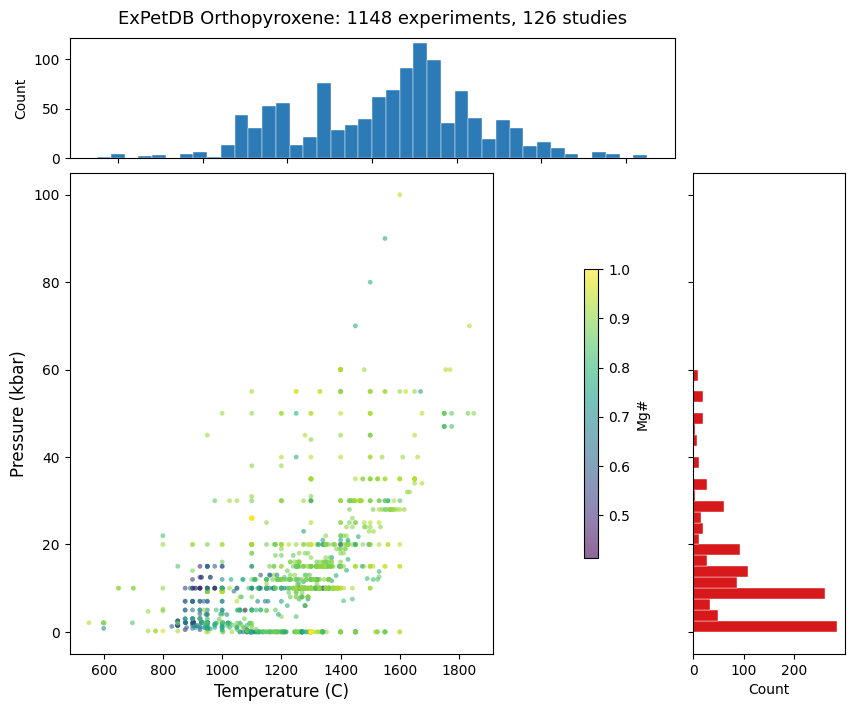

Saved fig01_pt_distribution.png


In [5]:
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                        hspace=0.05, wspace=0.05)

ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

sc = ax_main.scatter(df['T_C'], df['P_kbar'], c=df['Mg_num'], cmap='viridis',
                     s=12, alpha=0.6, edgecolors='none')
ax_main.set_xlabel('Temperature (C)', fontsize=12)
ax_main.set_ylabel('Pressure (kbar)', fontsize=12)
ax_main.invert_yaxis()
plt.colorbar(sc, ax=ax_main, pad=0.15, shrink=0.6, label='Mg#')

ax_top.hist(df['T_C'], bins=40, color='#2c7bb6', edgecolor='white', linewidth=0.3)
ax_top.set_ylabel('Count')
plt.setp(ax_top.get_xticklabels(), visible=False)

ax_right.hist(df['P_kbar'], bins=40, orientation='horizontal', color='#d7191c', edgecolor='white', linewidth=0.3)
ax_right.set_xlabel('Count')
ax_right.invert_yaxis()
plt.setp(ax_right.get_yticklabels(), visible=False)

ax_top.set_title(f'ExPetDB Orthopyroxene: {len(df)} experiments, {df["Citation"].nunique()} studies',
                 fontsize=13, pad=10)

fig.savefig(FIGURES / 'fig01_pt_distribution.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()
print('Saved fig01_pt_distribution.png')

## Figure 2: PCA Biplot

In [6]:
plt.tight_layout()
fig.savefig(FIGURES / 'fig02_pca_biplot.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()
print('Saved fig02_pca_biplot.png')

<Figure size 640x480 with 0 Axes>

Saved fig02_pca_biplot.png


## Correlation Heatmap

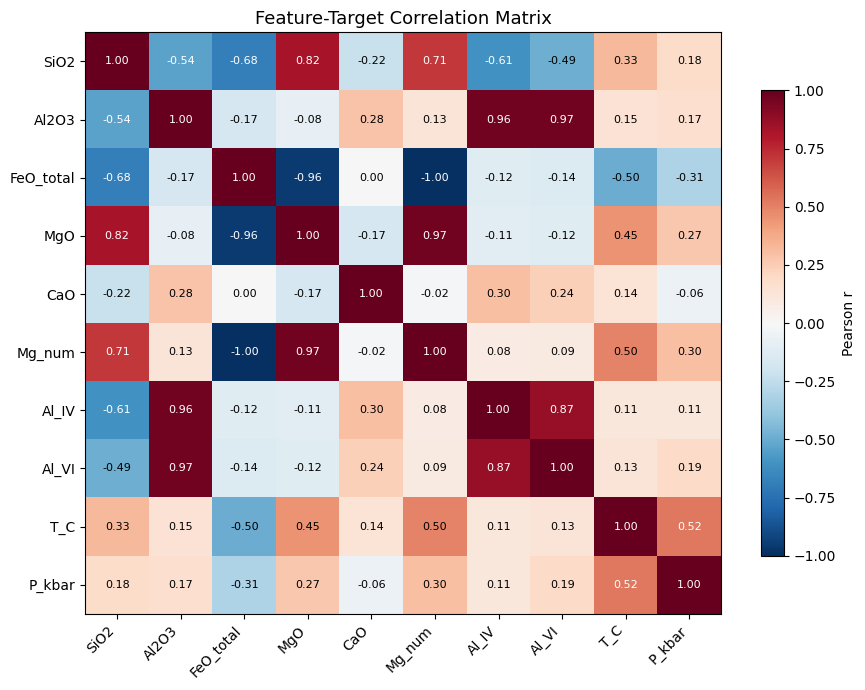

Saved fig_eda_correlation.png


In [7]:
corr_cols = ['SiO2', 'Al2O3', 'FeO_total', 'MgO', 'CaO', 'Mg_num', 'Al_IV', 'Al_VI', 'T_C', 'P_kbar']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(corr_cols, fontsize=10)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.8)
ax.set_title('Feature-Target Correlation Matrix', fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES / 'fig_eda_correlation.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()
print('Saved fig_eda_correlation.png')

## Oxide Distributions

In [8]:
plt.suptitle('Core Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES / 'fig_eda_distributions.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()
print('Saved fig_eda_distributions.png')
print('\nNotebook 02 complete.')

<Figure size 640x480 with 0 Axes>

Saved fig_eda_distributions.png

Notebook 02 complete.
